In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from decimal import Decimal

In [2]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:
# Data Loading
df = pd.read_csv('data_incentive_attitudes.csv')

# Some basic data preprocessing steps
df = df.drop('Unnamed: 0', axis='columns')
df = df.rename(columns={'pubcost':'traincost', 
                   'pubtime':'traintime', 
                   'pubavail':'trainavail',
                    'bicycleincentive':'bikeincentive'})

# Replacing 'pub' with 'train' in `mode` column.
selected_mode = df['mode'].to_numpy()
df['mode'] = np.where(selected_mode=='pub', 'train', selected_mode)

df.head()

,user_id,trip_id,departure_time,arrival_time,Purpose,buscost,bustime,carcost,cartime,cardistance,...,SEX,AGE,INCOME,recco,information,incentivezone,value,task,job_type,income_con
0,20006,99545,10/28/2020 17:51,10/28/2020 19:21,101,770,69.4,151.7,43.72,15.17,...,1,36,4,2,only enviro,0,1,1,company employee,9000000
1,20006,100663,10/29/2020 17:58,10/29/2020 19:14,101,690,66.2,128.6,38.96,12.86,...,1,36,4,2,only enviro,0,1,2,company employee,9000000
2,20006,101712,10/30/2020 17:39,10/30/2020 19:05,101,770,69.4,151.7,43.72,15.17,...,1,36,4,1,no info,0,1,3,company employee,9000000
3,20006,101878,10/30/2020 21:00,10/30/2020 21:25,998,500,56.2,118.5,29.53,11.85,...,1,36,4,1,no info,0,1,4,company employee,9000000
4,20006,100936,10/30/2020 7:14,10/30/2020 8:29,100,770,69.4,151.7,43.72,15.17,...,1,36,4,1,no info,0,1,5,company employee,9000000


In [4]:
basic_variables = list(df.columns)[:5]

purpose_code_dict = {100: 'Commuting to work / school',
                    101: 'Go Home',
                    200: 'Shopping for daily necessities',
                    201: 'Shopping other than daily necessities',
                    202: 'Meals and entertainment',
                    300: 'business',
                    400: 'Outpatient',
                    500: 'Pick-up and drop-off',
                    600: 'Sightseeing / Leisure',
                    998: 'others'}

alternative_specific_variables = list(df.columns)[5:29]
alternative_specific_variables.remove('mode')

attitudinal_variables = list(df.columns)[29:-10]
ohe_generic_variables = dict()

# <ins><b>Data Preprocessing</b></ins>

In [5]:
df['walkavail'] = np.where(df['mode']=='walk', 1, np.where(df['cardistance']<=7, 1, 0))

In [6]:
df['busincentive'] = np.where(df['incentivezone']==1, df['busincentive'], 0)
df['carincentive'] = np.where(df['incentivezone']==1, df['carincentive'], 0)
df['trainincentive'] = np.where(df['incentivezone']==1, df['trainincentive'], 0)
df['bikeincentive'] = np.where(df['incentivezone']==1, df['bikeincentive'], 0)
df['walkincentive'] = np.where(df['incentivezone']==1, df['walkincentive'], 0)
df['motorincentive'] = np.where(df['incentivezone']==1, df['motorincentive'], 0)


## Feature Encoding

In [7]:
from sklearn.preprocessing import OneHotEncoder
from datetime import datetime

In [8]:
ohe = OneHotEncoder()

In [9]:
# utility functions for extracting time-zones and trip duration information from arrival and departure times of a trip.

def get_trip_duration(df):
    """
    Returns the total minutes a trip lasted given its departure and arrival datetimes.
    """
    dep_datetime = datetime.strptime(df['departure_time'], '%m/%d/%Y %H:%M')
    arr_datetime = datetime.strptime(df['arrival_time'], '%m/%d/%Y %H:%M')
    
    return int((arr_datetime - dep_datetime).total_seconds()/60)

def get_day_zones(trip_datetime):
    """
    Divides the time into 4 zones and ordinally encoding them.
    Early morning (00:00 to 6:00) - 1
    AM peak (6:00 to 10:00) - 2
    Off peak (10:00 to 16:00) - 3
    PM peak (16:00 to 20:00) - 4
    Evening (20:00 to 00:00) - 5
    """
    dep_hrs, dep_mins = [int(val) for val in trip_datetime.split(' ')[1].split(':')]
    if dep_hrs >= 0 and dep_hrs < 6:
        return 1
    elif dep_hrs >= 6 and dep_hrs < 10:
        return 2
    elif dep_hrs >= 10 and dep_hrs < 16:
        return 3
    elif dep_hrs >= 16 and dep_hrs < 20:
        return 4
    else:
        return 5

In [10]:
# `job_type` column
job_type_sparse_matrix = ohe.fit_transform(df['job_type'].to_numpy().reshape(-1, 1)).toarray()
job_type_column_names = ['job_type_'+job for job in df['job_type'].unique()]
job_type_df = pd.DataFrame(data=job_type_sparse_matrix, columns=job_type_column_names)
job_type_df = job_type_df.drop(job_type_df.columns[0], axis=1)
ohe_generic_variables['jobs'] = list(job_type_df.columns)

# `information` column
info_sparse_matrix = ohe.fit_transform(df['information'].to_numpy().reshape(-1, 1)).toarray()
info_df = pd.DataFrame(data=info_sparse_matrix, columns=ohe.categories_[0])
info_df = info_df.drop(info_df.columns[0], axis=1)
ohe_generic_variables['info'] = list(info_df.columns)

# `SEX` column
SEX_sparse_matrix = ohe.fit_transform(df['SEX'].to_numpy().reshape(-1, 1)).toarray()
SEX_df = pd.DataFrame(data=SEX_sparse_matrix, columns=['Male', 'Female'])
SEX_df = SEX_df.drop(SEX_df.columns[0], axis=1)

# `Purpose` column
Purpose_sparse_matrix = ohe.fit_transform(df['Purpose'].to_numpy().reshape(-1, 1)).toarray()
Purpose_column_names = ['Purpose_'+str(purpose_code) for purpose_code in df['Purpose'].unique()]
Purpose_df = pd.DataFrame(data=Purpose_sparse_matrix, columns=Purpose_column_names)
Purpose_df = Purpose_df.drop('Purpose_999', axis=1)
ohe_generic_variables['purposes'] = list(Purpose_df.columns)

# Getting the trip duration in minutes
df['trip_duration'] = df[['departure_time', 'arrival_time']].T.apply(get_trip_duration)

# Converting departure time in time zones and one-hot encoding it
dep_time_zones_sparse_matrix = ohe.fit_transform(df['departure_time'].apply(get_day_zones).to_numpy().reshape(-1, 1)).toarray()
dep_time_zones_names = ['Early_morning_departure', 'AM_peak_departure', 'Off_peak_departure', 'PM_peak_departure', 'Night_departure']
dep_time_zones_df = pd.DataFrame(data=dep_time_zones_sparse_matrix, columns=dep_time_zones_names)
dep_time_zones_df = dep_time_zones_df.drop('Night_departure', axis=1)
ohe_generic_variables['departures'] = list(dep_time_zones_df.columns)

In [11]:
# combining all the one-hot encoded dataframes with the main dataframe
df2 = pd.concat([df, dep_time_zones_df, Purpose_df, SEX_df, job_type_df, info_df], axis=1).drop(
    ['departure_time', 'arrival_time', 'Purpose', 'SEX', 'job_type'], axis='columns')

# Removing some unnecessary columns
df2 = df2.drop(['user_id', 'trip_id', 'recco', 'information', 'incentivezone', 'task', 'income_con'], axis='columns')

df2.head()

,buscost,bustime,carcost,cartime,cardistance,traincost,traintime,walktime,walkcost,biketime,...,job_type_Part time job,job_type_Management executive,job_type_civil servant,job_type_Housewife,job_type_Self employed/ Freelance,job_type_Others,job_type_Unemployed,no info,only enviro,only health
0,770,69.4,151.7,43.72,15.17,240,60.9,182.04,0,60.68,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,690,66.2,128.6,38.96,12.86,240,44.9,154.32,0,51.44,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,770,69.4,151.7,43.72,15.17,240,60.9,182.04,0,60.68,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,500,56.2,118.5,29.53,11.85,400,59.0,142.20,0,47.40,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,770,69.4,151.7,43.72,15.17,240,60.9,182.04,0,60.68,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


<AxesSubplot:>

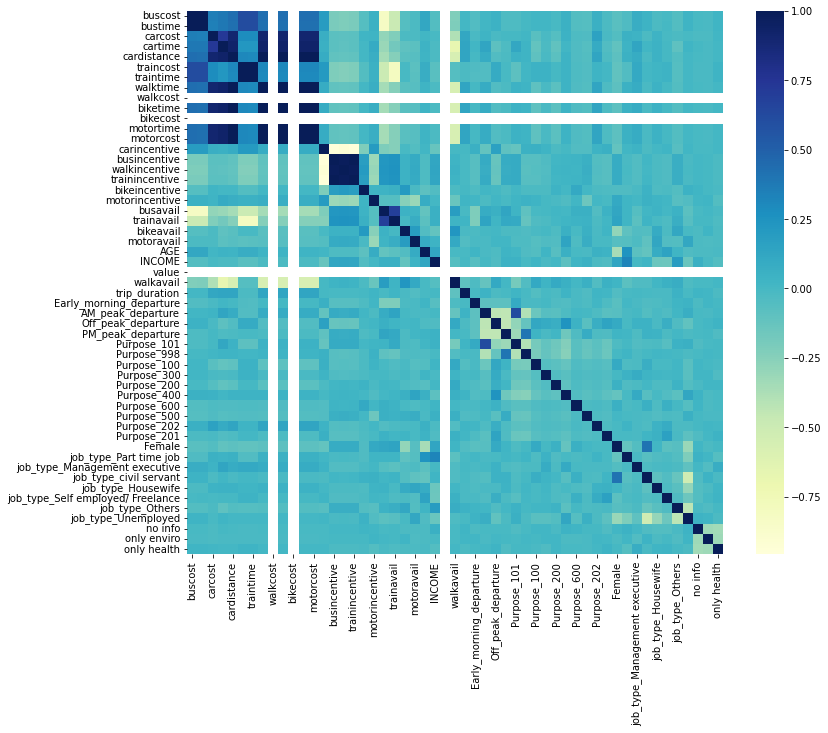

In [12]:
# all the alternative specific variables are heavily correlated with each other

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
sns.heatmap(df2.drop(attitudinal_variables, axis='columns').corr(numeric_only=True), cmap='YlGnBu', annot=False, ax=ax)

## Dealing with outliers

In [13]:
df4 = df2.copy()

In [14]:
def winsorize_single_variable(df, var_name, delta=2):
    # Quantile based winsorization on trip duration
    Q1 = df[var_name].quantile(0.25)
    Q3 = df[var_name].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + delta*IQR
    var = df[var_name].to_numpy()
    var = np.where((var <= upper_bound), var, upper_bound)

    df[var_name] = var
    return df

In [15]:
def winsorize_multiple_variables(df, var_name_list, delta=1.9):
    for i in range(len(var_name_list)):
        Q1 = df[var_name_list[i]].quantile(0.25)
        Q3 = df[var_name_list[i]].quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + delta * IQR
        lower_bound = Q1 - delta * IQR
        var_arr = df[var_name_list[i]].to_numpy()
        df[var_name_list[i]] = np.where((var_arr <= upper_bound) & (var_arr >= lower_bound), var_arr, upper_bound)
    return df

In [16]:
df4 = winsorize_single_variable(df4, 'trip_duration')
df4 = winsorize_multiple_variables(df4, list(alternative_specific_variables[:-4]))

## Train and Test Split

In [17]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.preprocessing import StandardScaler

In [18]:
def get_train_test_data(df, drop_att_vars=True, apply_smote=False, apply_tomek_links=False, 
                        apply_standardization=False, cols_to_standardize=[]):
    if drop_att_vars:
        df = df.drop(attitudinal_variables, axis='columns')
    
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=500)
    
    label_mapping_dict = {'bus': 1, 'car': 2, 'train': 3, 'walk': 4, 'bike': 5, 'motor': 6}
    
    y_train = np.array([label_mapping_dict[label] for label in train_df['mode']])
    X_train = train_df.drop('mode', axis='columns')
    y_test = np.array([label_mapping_dict[label] for label in test_df['mode']])
    X_test = test_df.drop('mode', axis='columns')
    
    if apply_smote:
        smote = SMOTE(random_state=500)
        X_train, y_train = smote.fit_resample(X_train, y_train)
        X_test, y_test = smote.fit_resample(X_test, y_test)
    
    if apply_tomek_links:
        tomek = TomekLinks()
        X_train, y_train = tomek.fit_resample(X_train, y_train)
        X_test, y_test = tomek.fit_resample(X_test, y_test)
    
    if apply_standardization:
        ss =  StandardScaler()
        X_train_scaled_arr = ss.fit_transform(X_train[cols_to_standardize])
        X_test_scaled_arr = ss.transform(X_test[cols_to_standardize])
        X_train_scaled = pd.DataFrame(X_train_scaled_arr, columns=cols_to_standardize)
        X_test_scaled = pd.DataFrame(X_test_scaled_arr, columns=cols_to_standardize)
        X_train_scaled.set_index(X_train.index, inplace=True)
        X_test_scaled.set_index(X_test.index, inplace=True)
        X_train.iloc[0:X_train.shape[0], X_train.columns.get_indexer(cols_to_standardize)] = X_train_scaled
        X_test.iloc[0:X_test.shape[0], X_test.columns.get_indexer(cols_to_standardize)] = X_test_scaled
        
    return ((X_train, y_train), (X_test, y_test)), label_mapping_dict

In [19]:
output_categories = ['bus', 'car', 'train', 'walk', 'bike', 'motor']

asc_variable_names = {
    'bus': ['buscost', 'bustime', 'busincentive'],
    'car': ['carcost', 'cartime', 'carincentive'],
    'train': ['traincost', 'traintime', 'trainincentive'], 
    'walk': ['walkcost', 'walktime', 'walkincentive'],
    'bike': [ 'bikecost', 'biketime', 'bikeincentive'],
    'motor': ['motorcost', 'motortime', 'motorincentive']
}

avail_variable_names = {
    'bus': 'busavail',
    'train': 'trainavail',
    'walk': 'walkavail',
    'bike': 'bikeavail',
    'motor': 'motoravail'
}

In [20]:
cols_to_standardize = ['AGE']
for category in output_categories:
    cols_to_standardize.extend(asc_variable_names[category])

In [298]:
((X_train, y_train), (X_test, y_test)), label_mapping_dict = get_train_test_data(df2, drop_att_vars=True,
                                                                apply_smote=False,
                                                                apply_tomek_links=False,
                                                                apply_standardization=False, 
                                                                cols_to_standardize=cols_to_standardize)
label_mapping_dict

{'bus': 1, 'car': 2, 'train': 3, 'walk': 4, 'bike': 5, 'motor': 6}

In [299]:
def get_generic_vars_names(asc_variable_names, avail_variable_names):
    asc_variables_list = []
    for category_asc_variables in asc_variable_names.values():
        asc_variables_list.extend(category_asc_variables)
    return list(X_train.drop(asc_variables_list, axis=1, errors='ignore').drop(
        avail_variable_names.values(), axis=1, errors='ignore').columns)

In [300]:
generic_variable_names = get_generic_vars_names(asc_variable_names, avail_variable_names)
for item in ['cardistance', 'trip_duration']:
    if item in generic_variable_names:
        generic_variable_names.remove(item)

asc_variable_indexer = dict()
for category in output_categories:
    asc_variable_indexer[category] = X_train.columns.get_indexer(asc_variable_names[category])

avail_variable_indexer = dict(zip(avail_variable_names.keys(), 
                                  X_train.columns.get_indexer(avail_variable_names.values())))

generic_variable_indexer = dict(zip(generic_variable_names, 
                                  X_train.columns.get_indexer(generic_variable_names)))

# <ins><b>Model Formulation</b></ins>

In [301]:
import tensorflow as tf
import tensorflow_probability as tfp

import functools
import contextlib
import time

tf.get_logger().setLevel('INFO')

In [302]:
# Helper functions

def make_val_and_grad_fn(value_fn):
    @functools.wraps(value_fn)
    def val_and_grad(x):
        return tfp.math.value_and_gradient(value_fn, x)
    return val_and_grad

@contextlib.contextmanager
def timed_execution():
    t0 = time.time()
    yield
    dt = time.time() - t0
    print('Evaluation took: %f seconds' % dt)


def np_value(tensor):
    """Get numpy value out of possibly nested tuple of tensors."""
    if isinstance(tensor, tuple):
        return type(tensor)(*(np_value(t) for t in tensor))
    else:
        return tensor.numpy()

def run(optimizer):
    """Run an optimizer and measure it's evaluation time."""
    optimizer()  # Warmup.
    with timed_execution():
        result = optimizer()
    return np_value(result)

In [303]:
def generate_avail_data(X):
    avail_vals = []
    for cat in output_categories:
        if cat in avail_variable_names:
            avail_vals.append(X[avail_variable_names[cat]].to_numpy())
        else:
            avail_vals.append(np.ones((X.shape[0]), dtype='int64'))
    avail_vals = np.vstack(avail_vals)
    avail_vals = tf.cast(avail_vals, dtype='float32')
    return avail_vals

In [304]:
def initiate_params(alt_spec_vars=True, ind_spec_vars=False):
    model_params = []
    
    if alt_spec_vars:
        # Generic parameters for alternative specific variables of travelcost, traveltime, travelincentive
        gen_tc = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='travelcost', trainable=True)
        gen_tt = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='traveltime', trainable=True)
        gen_ti = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='travelincentive', trainable=True)
        model_params.extend([gen_tc, gen_tt, gen_ti])

        # Alternative specific constants for bus, train, walk, bike, motor
        asc_bus = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='bus_constant', trainable=True)
        asc_train = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='train_constant', trainable=True)
        asc_walk = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='walk_constant', trainable=True)
        asc_bike = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='bike_constant', trainable=True)
        asc_motor = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='motor_constant', trainable=True)
        model_params.extend([asc_bus, asc_train, asc_walk, asc_bike, asc_motor])
    
#     if ind_spec_vars:
#         # Alternative specific paramters for individual specific variables AGE, INCOME, 4 departures, 10 purposes, female gender, 7 job types, 3 info variables
#         asp_age_bus = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='age_bus', trainable=True)
#         asp_age_train = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='age_train', trainable=True)
#         asp_age_walk = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='age_walk', trainable=True)
#         asp_age_bike = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='age_bike', trainable=True)
#         asp_age_motor = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='age_motor', trainable=True)
#         model_params.extend([asp_age_bus, asp_age_train, asp_age_walk, asp_age_bike, asp_age_motor])

#         asp_income_bus = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='income_bus', trainable=True)
#         asp_income_train = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='income_train', trainable=True)
#         asp_income_walk = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='income_walk', trainable=True)
#         asp_income_bike = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='income_bike', trainable=True)
#         asp_income_motor = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='income_motor', trainable=True)
#         model_params.extend([asp_income_bus, asp_income_train, asp_income_walk, asp_income_bike, asp_income_motor])

#         asp_female_bus = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='female_bus', trainable=True)
#         asp_female_train = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='female_train', trainable=True)
#         asp_female_walk = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='female_walk', trainable=True)
#         asp_female_bike = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='female_bike', trainable=True)
#         asp_female_motor = tf.Variable(tf.zeros([1,]), dtype=tf.float32, name='female_motor', trainable=True)
#         model_params.extend([asp_female_bus, asp_female_train, asp_female_walk, asp_female_bike, asp_female_motor])

#         asp_jobs = []
#         for i in range(7):
#             curr_job_params = []
#             curr_job_params.append(tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'job{i+1}_bus', trainable=True))
#             curr_job_params.append(tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'job{i+1}_train', trainable=True))
#             curr_job_params.append(tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'job{i+1}_walk', trainable=True))
#             curr_job_params.append(tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'job{i+1}_bike', trainable=True))
#             curr_job_params.append(tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'job{i+1}_motor', trainable=True))
#             asp_jobs.append(curr_job_params)
#             model_params.extend(curr_job_params)

#         asp_departures = []
#         for i in range(4):
#             curr_departure_params = []
#             curr_departure_params.append(tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'departure{i+1}_bus', trainable=True))
#             curr_departure_params.append(tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'departure{i+1}_train', trainable=True))
#             curr_departure_params.append(tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'departure{i+1}_walk', trainable=True))
#             curr_departure_params.append(tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'departure{i+1}_bike', trainable=True))
#             curr_departure_params.append(tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'departure{i+1}_motor', trainable=True))
#             asp_departures.append(curr_departure_params)
#             model_params.extend(curr_departure_params)

#         asp_purposes = []
#         for i in range(10):
#             curr_purpose_params = []
#             curr_purpose_params.append(tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'purpose{i+1}_bus', trainable=True))
#             curr_purpose_params.append(tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'purpose{i+1}_train', trainable=True))
#             curr_purpose_params.append(tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'purpose{i+1}_walk', trainable=True))
#             curr_purpose_params.append(tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'purpose{i+1}_bike', trainable=True))
#             curr_purpose_params.append(tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'purpose{i+1}_motor', trainable=True))
#             asp_purposes.append(curr_purpose_params)
#             model_params.extend(curr_purpose_params)

#         asp_info = []
#         for i in range(3):
#             curr_info_params = []
#             curr_info_params.append(tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'info{i+1}_bus', trainable=True))
#             curr_info_params.append(tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'info{i+1}_train', trainable=True))
#             curr_info_params.append(tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'info{i+1}_walk', trainable=True))
#             curr_info_params.append(tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'info{i+1}_bike', trainable=True))
#             curr_info_params.append(tf.Variable(tf.zeros([1,]), dtype=tf.float32, name=f'info{i+1}_motor', trainable=True))
#             asp_info.append(curr_info_params)
#             model_params.extend(curr_info_params)
    
    return model_params


In [305]:
def utilities(x_name, x_val, params, alt_spec_vars=True, ind_spec_vars=False):
    ntrips = x_val.shape[-1]
    X = {name:val for name, val in zip(x_name, x_val.T)}
    
    if alt_spec_vars:
        gen_tc, gen_tt, gen_ti = params[:3]
        asc_bus, asc_train, asc_walk, asc_bike, asc_motor = params[3:8]
#     if ind_spec_vars:
#         asp_age_bus, asp_age_train, asp_age_walk, asp_age_bike, asp_age_motor = params[8:13]
#         asp_income_bus, asp_income_train, asp_income_walk, asp_income_bike, asp_income_motor = params[13:18]
#         asp_female_bus, asp_female_train, asp_female_walk, asp_female_bike, asp_female_motor = params[18:23]
#         asp_jobs = params[23:(23+35)]
#         asp_departures = params[(23+35):(23+35+20)]
#         asp_purposes = params[(23+35+20):(23+35+20+50)]
#         asp_info = params[(23+35+20+50):(23+35+20+50+15)]
    
    utility_bus = tf.Variable(0.0);utility_train = tf.Variable(0.0);utility_car = tf.Variable(0.0)
    utility_walk = tf.Variable(0.0);utility_bike = tf.Variable(0.0);utility_motor = tf.Variable(0.0)
    
    if alt_spec_vars:
        # contribution to utility from tc, tt, ti
        travel_util_bus = X['buscost']*gen_tc + X['bustime']*gen_tt + X['busincentive']*gen_ti + asc_bus
        travel_util_train = X['traincost']*gen_tc + X['traintime']*gen_tt + X['trainincentive']*gen_ti + asc_train
        travel_util_walk = X['walktime']*gen_tt + X['walkincentive']*gen_ti + asc_walk # walkcost is 0
        travel_util_bike = X['biketime']*gen_tt + X['bikeincentive']*gen_ti + asc_bike # bikecost is 0
        travel_util_motor = X['motorcost']*gen_tc + X['motortime']*gen_tt + X['motorincentive']*gen_ti + asc_motor
        travel_util_car = X['carcost']*gen_tc + X['cartime']*gen_tt + X['carincentive']*gen_ti
        
        utility_bus = travel_util_bus; utility_car = travel_util_car; utility_train = travel_util_train
        utility_walk = travel_util_walk; utility_bike = travel_util_bike; utility_motor = travel_util_motor
    
#     if ind_spec_vars:
#         # Contribution to utility due to age
#         age_util_bus = X['AGE']*asp_age_bus
#         age_util_train = X['AGE']*asp_age_train
#         age_util_walk = X['AGE']*asp_age_walk
#         age_util_bike = X['AGE']*asp_age_bike
#         age_util_motor = X['AGE']*asp_age_motor

#         # Contribution to utility due to income
#         income_util_bus = X['INCOME']*asp_income_bus
#         income_util_train = X['INCOME']*asp_income_train
#         income_util_walk = X['INCOME']*asp_income_walk
#         income_util_bike = X['INCOME']*asp_income_bike
#         income_util_motor = X['INCOME']*asp_income_motor

#         # Contribution to utility due to gender
#         gender_util_bus = X['Female']*asp_female_bus
#         gender_util_train = X['Female']*asp_female_train
#         gender_util_walk = X['Female']*asp_female_walk
#         gender_util_bike = X['Female']*asp_female_bike
#         gender_util_motor = X['Female']*asp_female_motor

#         # Contribution to utility due to jobs
#         job_util_bus = tf.reduce_sum([curr_job_params[0]*X[ohe_generic_variables['jobs'][i]] for i, curr_job_params in enumerate(asp_jobs)], axis=0)
#         job_util_train = tf.reduce_sum([curr_job_params[1]*X[ohe_generic_variables['jobs'][i]] for i, curr_job_params in enumerate(asp_jobs)], axis=0)
#         job_util_walk = tf.reduce_sum([curr_job_params[2]*X[ohe_generic_variables['jobs'][i]] for i, curr_job_params in enumerate(asp_jobs)], axis=0)
#         job_util_bike = tf.reduce_sum([curr_job_params[3]*X[ohe_generic_variables['jobs'][i]] for i, curr_job_params in enumerate(asp_jobs)], axis=0)
#         job_util_motor = tf.reduce_sum([curr_job_params[4]*X[ohe_generic_variables['jobs'][i]] for i, curr_job_params in enumerate(asp_jobs)], axis=0)

#         # Contribution to utility due to info
#         info_util_bus = tf.reduce_sum([curr_job_params[0]*X[ohe_generic_variables['info'][i]] for i, curr_job_params in enumerate(asp_info)], axis=0)
#         info_util_train = tf.reduce_sum([curr_job_params[1]*X[ohe_generic_variables['info'][i]] for i, curr_job_params in enumerate(asp_info)], axis=0)
#         info_util_walk = tf.reduce_sum([curr_job_params[2]*X[ohe_generic_variables['info'][i]] for i, curr_job_params in enumerate(asp_info)], axis=0)
#         info_util_bike = tf.reduce_sum([curr_job_params[3]*X[ohe_generic_variables['info'][i]] for i, curr_job_params in enumerate(asp_info)], axis=0)
#         info_util_motor = tf.reduce_sum([curr_job_params[4]*X[ohe_generic_variables['info'][i]] for i, curr_job_params in enumerate(asp_info)], axis=0)

#         # Contribution to utility due to departures
#         dep_util_bus = tf.reduce_sum([curr_job_params[0]*X[ohe_generic_variables['departures'][i]] for i, curr_job_params in enumerate(asp_departures)], axis=0)
#         dep_util_train = tf.reduce_sum([curr_job_params[1]*X[ohe_generic_variables['departures'][i]] for i, curr_job_params in enumerate(asp_departures)], axis=0)
#         dep_util_walk = tf.reduce_sum([curr_job_params[2]*X[ohe_generic_variables['departures'][i]] for i, curr_job_params in enumerate(asp_departures)], axis=0)
#         dep_util_bike = tf.reduce_sum([curr_job_params[3]*X[ohe_generic_variables['departures'][i]] for i, curr_job_params in enumerate(asp_departures)], axis=0)
#         dep_util_motor = tf.reduce_sum([curr_job_params[4]*X[ohe_generic_variables['departures'][i]] for i, curr_job_params in enumerate(asp_departures)], axis=0)

#         # Contribution to utility due to purposes
#         purpose_util_bus = tf.reduce_sum([curr_job_params[0]*X[ohe_generic_variables['purposes'][i]] for i, curr_job_params in enumerate(asp_purposes)], axis=0)
#         purpose_util_train = tf.reduce_sum([curr_job_params[1]*X[ohe_generic_variables['purposes'][i]] for i, curr_job_params in enumerate(asp_purposes)], axis=0)
#         purpose_util_walk = tf.reduce_sum([curr_job_params[2]*X[ohe_generic_variables['purposes'][i]] for i, curr_job_params in enumerate(asp_purposes)], axis=0)
#         purpose_util_bike = tf.reduce_sum([curr_job_params[3]*X[ohe_generic_variables['purposes'][i]] for i, curr_job_params in enumerate(asp_purposes)], axis=0)
#         purpose_util_motor = tf.reduce_sum([curr_job_params[4]*X[ohe_generic_variables['purposes'][i]] for i, curr_job_params in enumerate(asp_purposes)], axis=0)
    
#         utility_bus += age_util_bus + income_util_bus + gender_util_bus + job_util_bus + info_util_bus + dep_util_bus + purpose_util_bus
#         utility_train += age_util_train + income_util_train + gender_util_train + job_util_train + info_util_train + dep_util_train + purpose_util_train
#         utility_walk += age_util_walk + income_util_walk + gender_util_walk + job_util_walk + info_util_walk + dep_util_walk + purpose_util_walk
#         utility_bike += age_util_bike + income_util_bike + gender_util_bike + job_util_bike + info_util_bike + dep_util_bike + purpose_util_bike
#         utility_motor += age_util_motor + income_util_motor + gender_util_motor + job_util_motor + info_util_motor + dep_util_motor + purpose_util_motor

    return tf.transpose(tf.stack((utility_bus, utility_car, utility_train, utility_walk, utility_bike, utility_motor)))

In [306]:
def loss(true_y, utilities, avail_vals):
    initial_probs = tf.nn.softmax(utilities)
    masked_probs = initial_probs*tf.transpose(avail_vals)
    final_probs = tf.divide(masked_probs, 
                            tf.reshape((tf.reduce_sum(masked_probs, axis=-1) + tf.keras.backend.epsilon()), 
                                       [-1, 1])
                           )
    return -tf.reduce_mean(tf.reduce_sum(true_y*tf.math.log(final_probs + tf.keras.backend.epsilon()), axis=-1))
    

## Training with BFGS optimizer

In [307]:
params = initiate_params()
ohe_true_y = tf.one_hot(y_train-1, 6, on_value=1, off_value=0, axis=-1, dtype='float32')
avail_vals = generate_avail_data(X_train)
x_names = X_train.columns
x_vals = X_train.values

In [308]:
@make_val_and_grad_fn
def loss_val_nd_loss_grad(params):
    curr_utils = utilities(x_names, x_vals, params)
    curr_loss = loss(ohe_true_y, curr_utils, avail_vals)
    return curr_loss

In [315]:
def mnl_with_bfgs():
    return tfp.optimizer.bfgs_minimize(loss_val_nd_loss_grad, 
                                       initial_position=tf.reshape(params, shape=[-1]),
                                      tolerance=1e-10,
                                      max_iterations=500)

In [316]:
results = run(mnl_with_bfgs)

print('BFGS Results')
print('Converged:', results.converged)
print('Location of the minimum:', results.position)
print('Number of iterations:', results.num_iterations)

Evaluation took: 5.528775 seconds
BFGS Results
Converged: True
Location of the minimum: [-0.00185328 -0.0550028   0.0019704  -0.56643784 -0.7351888  -0.01712801
 -0.19814484 -0.1822824 ]
Number of iterations: 29


In [317]:
std_errors = np.sqrt(np.diagonal(results.inverse_hessian_estimate))/np.sqrt(len(ohe_true_y))

In [318]:
t_ratios = results.position/std_errors

In [321]:
var_names = ['gen_tc', 'gen_tt', 'gen_ti', 'asc_bus', 'asc_train', 'asc_walk', 'asc_bike', 'asc_motor']
data_dict = {'variable':var_names, 'estimates':results.position, 'std_errors':std_errors, 't ratios':t_ratios}
bfgs_res = pd.DataFrame(data_dict)
bfgs_res

,variable,estimates,std_errors,t ratios
0,gen_tc,-0.001853,0.000313,-5.918855
1,gen_tt,-0.055003,0.003913,-14.058132
2,gen_ti,0.001970,0.000285,6.920025
3,asc_bus,-0.566438,0.167641,-3.378878
4,asc_train,-0.735189,0.122353,-6.008740
5,asc_walk,-0.017128,0.118254,-0.144841
6,asc_bike,-0.198145,0.079923,-2.479187
7,asc_motor,-0.182282,0.074474,-2.447609


In [343]:
initial_mean_negLL = loss_val_nd_loss_grad(tf.reshape(initiate_params(), shape=[-1]))[0].numpy()
final_mean_negLL = loss_val_nd_loss_grad(bfgs_res['estimates'].to_numpy())[0].numpy()
print(f"Initial -log loss {initial_mean_negLL:.2f}")
print(f'Final -log loss {final_mean_negLL:.2f}')

Initial -log loss 1.14
Final -log loss 0.82


In [349]:
AIC = 2*(len(bfgs_res)+final_mean_negLL*len(x_vals))
AIC

4049.911055088043

In [322]:
classical_res = pd.read_csv('classical_model/MNL_2762023_estimates.csv')
classical_res.rename(columns={'Unnamed: 0':'variable'}, inplace=True)
classical_res['variable'] = ['asc_bike', 'asc_bus', 'asc_motor', 'asc_train', 'asc_walk', 'gen_tc', 'gen_tt', 'gen_ti']
classical_res

,variable,Estimate,Std.err.,t-ratio(0),Rob.std.err.,Rob.t-ratio(0)
0,asc_bike,-0.173201,0.085611,-2.023101,0.245170,-0.706452
1,asc_bus,-0.490740,0.157921,-3.107505,0.407143,-1.205325
2,asc_motor,-0.190631,0.114749,-1.661292,0.419203,-0.454746
3,asc_train,-0.726152,0.113866,-6.377263,0.378037,-1.920847
4,asc_walk,0.036478,0.111535,0.327053,0.314563,0.115964
5,gen_tc,-0.001925,0.000328,-5.865268,0.000771,-2.496885
6,gen_tt,-0.059405,0.003642,-16.309221,0.014402,-4.124704
7,gen_ti,0.001954,0.000258,7.567342,0.000579,3.376671


## Training the model with adam's optimizer

In [323]:
class EvaluationMetrics(object):
    def __init__(self, metrics_dict=None):
        if metrics_dict is None:
            metrics_dict = {'Loss':[], 'Accuracy':[], 'Precision':[], 'Recall':[], 'F1Score':[]}
        self.metrics_dict = metrics_dict
        self.batch_metrics_dict = None
        
    def precision(self, y_true, y_pred, average='macro'):
        num_classes = tf.reduce_max(y_true)

        precision_values = tf.TensorArray(tf.float32, size=num_classes, dynamic_size=False)

        for class_label in range(1, num_classes + 1):
            true_positives = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_true, class_label), tf.equal(y_pred, class_label)), tf.float32))
            false_positives = tf.reduce_sum(tf.cast(tf.logical_and(tf.not_equal(y_true, class_label), tf.equal(y_pred, class_label)), tf.float32))

            precision_value = true_positives / (true_positives + false_positives + 1e-7)
            precision_values = precision_values.write(class_label - 1, precision_value)

        precision_values = precision_values.stack()

        if average == 'macro':
            precision_mean = tf.reduce_mean(precision_values)
            return precision_mean
        elif average == 'micro':
            true_positives_total = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_true, y_pred), tf.not_equal(y_pred, -1)), tf.float32))
            false_positives_total = tf.reduce_sum(tf.cast(tf.logical_and(tf.not_equal(y_true, y_pred), tf.equal(y_pred, -1)), tf.float32))
            precision_micro = true_positives_total / (true_positives_total + false_positives_total + 1e-7)
            return precision_micro
        else:
            return precision_values
    
    
    def recall(self, y_true, y_pred, average='macro'):
        num_classes = tf.reduce_max(y_true)

        recall_values = tf.TensorArray(tf.float32, size=num_classes, dynamic_size=False)

        for class_label in range(1, num_classes+1):
            true_positives = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_true, class_label), tf.equal(y_pred, class_label)), tf.float32))
            false_negatives = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_true, class_label), tf.not_equal(y_pred, class_label)), tf.float32))

            recall_value = true_positives / (true_positives + false_negatives + 1e-7)
            recall_values = recall_values.write(class_label - 1, recall_value)
        
        recall_values = recall_values.stack()
        
        if average == 'macro':
            recall_mean = tf.reduce_mean(recall_values)
            return recall_mean
        elif average == 'micro':
            true_positives_total = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_true, y_pred), tf.not_equal(y_pred, -1)), tf.float32))
            false_negatives_total = tf.reduce_sum(tf.cast(tf.logical_and(tf.not_equal(y_true, y_pred), tf.equal(y_pred, -1)), tf.float32))
            recall_micro = true_positives_total / (true_positives_total + false_negatives_total + 1e-7)
            return recall_micro
        
        return recall_values
    
    
    def f1_score(self, y_true, y_pred, average='macro'):
        precisions = self.precision(y_true, y_pred, average=average)
        recalls = self.recall(y_true, y_pred, average=average)

        f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-7)
        
        return f1_scores
    
    
    def accuracy(self, y_true, y_pred):
        correct_predictions = tf.cast(tf.equal(y_true, y_pred), dtype=tf.float32)
        accuracy = tf.reduce_mean(correct_predictions)
        
        return accuracy
    
    
    def update_epoch_metrics(self, print_results=False):
        if self.batch_metrics_dict is not None:
            epoch_loss = tf.reduce_mean(self.batch_metrics_dict['Loss'])
            epoch_accuracy = tf.reduce_mean(self.batch_metrics_dict['Accuracy'])
            epoch_precision = tf.reduce_mean(self.batch_metrics_dict['Precision'])
            epoch_recall = tf.reduce_mean(self.batch_metrics_dict['Recall'])
            epoch_f1score = tf.reduce_mean(self.batch_metrics_dict['F1Score'])
        else:
            raise Exception('Batch metrics are not calculated yet.')
            
        self.metrics_dict['Loss'].append(epoch_loss)
        self.metrics_dict['Accuracy'].append(epoch_accuracy)
        self.metrics_dict['Precision'].append(epoch_precision)
        self.metrics_dict['Recall'].append(epoch_recall)
        self.metrics_dict['F1Score'].append(epoch_f1score)
        
        
        if print_results:
            print("---------------------------------------")
            print(f'Mean -ve log-likelihood: {epoch_loss:.3f}')
            print(f'Accuracy: {epoch_accuracy:.3f}')
            print(f'Precision: {epoch_precision:.3f}')
            print(f'Recall: {epoch_recall:.3f}')
            print(f'F1-Score: {epoch_f1score:.3f}')
            print("---------------------------------------")

        
        self.batch_metrics_dict = None

    
    def update_batch_metrics(self, y_true, y_pred, loss, average='macro', batch_metrics_dict=None):
        
        if self.batch_metrics_dict is None:
            self.batch_metrics_dict = {'Loss':[], 'Precision':[], 'Accuracy':[], 'Recall':[], 'F1Score':[]}
        
        if len(y_pred.shape) != 1:
            y_pred = tf.argmax(y_pred, axis=-1)
        
        y_true = tf.cast(y_true, dtype='int32')
        y_pred = tf.cast(y_pred, dtype='int32')
        
        curr_precision = self.precision(y_true, y_pred, average=average)
        self.batch_metrics_dict['Precision'].append(curr_precision)
        
        curr_recall = self.recall(y_true, y_pred, average=average)
        self.batch_metrics_dict['Recall'].append(curr_recall)
        
        curr_f1_score = self.f1_score(y_true, y_pred, average=average)
        self.batch_metrics_dict['F1Score'].append(curr_f1_score)
        
        curr_accuracy = self.accuracy(y_true, y_pred)
        self.batch_metrics_dict['Accuracy'].append(curr_accuracy)
        
        self.batch_metrics_dict['Loss'].append(loss)
    
    
    def metrics_variation_plots(self, ax=None, label=''):
        if ax is None:
            fig, ax = plt.subplots(2, 2, figsize=(15, 10))
        
        ax[0, 0].plot(np.arange(len(self.metrics_dict['Loss'])), self.metrics_dict['Loss'], marker='o', lw=1, label=label)
        ax[0, 0].set_ylabel('Mean negative log-likelihood (MNLL)')
        
        ax[0, 1].plot(np.arange(len(self.metrics_dict['Accuracy'])), self.metrics_dict['Accuracy'], marker='o', lw=1, label=label)
        ax[0, 1].set_ylabel('Accuracy')
        
        ax[1, 0].plot(np.arange(len(self.metrics_dict['Precision'])), self.metrics_dict['Precision'], marker='o', lw=1, label=label)
        ax[1, 0].set_ylabel('Precision')
        
        ax[1, 1].plot(np.arange(len(self.metrics_dict['Recall'])), self.metrics_dict['Recall'], marker='o', lw=1, label=label)
        ax[1, 1].set_ylabel('Recall')
        
    
    def reset_states(self):
        for metric, _ in self.metrics_dict.items():
            self.metrics_dict[metric] = []


In [327]:
EPOCHS = 1000
learning_rate = 0.001

params = initiate_params()
ohe_true_y = tf.one_hot(y_train-1, 6, on_value=1, off_value=0, axis=-1, dtype='float32')
avail_vals = generate_avail_data(X_train)
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
eval_metrics = EvaluationMetrics()

for i in range(EPOCHS):
    with tf.GradientTape() as tape:
        curr_utils = utilities(X_train.columns, X_train.values, params)
        curr_loss = loss(ohe_true_y, curr_utils, avail_vals)
    grads = tape.gradient(curr_loss, params)
    optimizer.apply_gradients(zip(grads, params))
    eval_metrics.update_batch_metrics(y_train-1, curr_utils, curr_loss)
    eval_metrics.update_epoch_metrics(print_results=False)


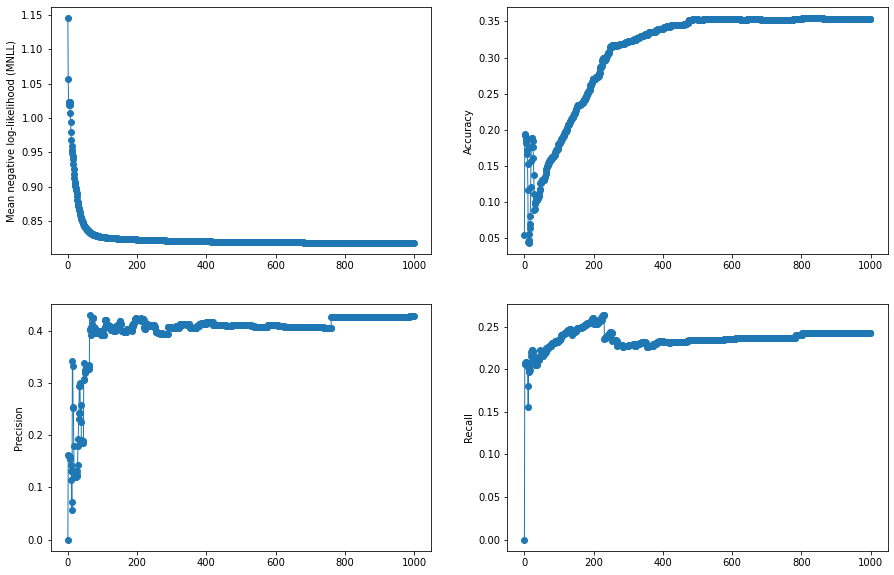

In [328]:
eval_metrics.metrics_variation_plots()

In [330]:
for i in range(len(params)):
    print(f"{params[i].name.strip(':0')}: {params[i][0]:.5f}")

travelcost: -0.00231
traveltime: -0.05981
travelincentive: 0.00178
bus_constant: -0.25669
train_constant: -0.50135
walk_constant: 0.13373
bike_constant: -0.15863
motor_constant: -0.17148
